# Stress test: sampling time vs $n$

Expressions: $e_{\mathrm{ex1}}$, $e_{\mathrm{ex2}}$, $e_{\mathrm{ex3}}$, $e_{\mathrm{exb}}$.  
Hard budget: **20 min per expression**. Mean wall-clock time shown; no scatter.

In [4]:
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")  # works with matplotlib-inline 0.2.x
import sys, os, time, random
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def _find_repo_root():
    try:
        d = os.path.abspath(os.getcwd())
    except (FileNotFoundError, OSError):
        d = '/workspace'
    while True:
        if os.path.isfile(os.path.join(d, 'parse', 'quickparse.py')):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            raise RuntimeError('Could not find repo root (parse/quickparse.py)')
        d = parent

REPO = _find_repo_root()
PAPER_EXP = os.path.join(REPO, 'experiments', 'paper_experiments')
for p in [REPO, PAPER_EXP]:
    if p not in sys.path: sys.path.insert(0, p)

from parse.quickparse import quickparse
from sample.sample import sample
from volume.slice_volume import slice_volume
from plot_config import *
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.serif": [],
    "font.weight": "normal",
})

random.seed(42); np.random.seed(42)

phi_test = quickparse('<a>_[0,1] *', string=True)
w = sample(phi_test, 3)
print('VolTRE OK:', w)


VolTRE OK: (0.389, a),(0.816, a),(0.485, a)


In [5]:
import matplotlib.pyplot as plt

phi_ex1 = quickparse('<a>_[0,1] *', string=True)
phi_ex2 = quickparse('a * . <a . a>_[0,1] . a *', string=True)
phi_ex3 = quickparse('(<a . a>_[0,1] . a) & (a . <a . a>_[0,1])', string=True)
phi_exb = quickparse('<b>_[3,4] * . (<a>_[1,2] . <b>_[3,4] . <b>_[3,4] *) *', string=True)
phi_ex3_left  = quickparse('(<a . a>_[0,1] . a)', string=True)
phi_ex3_right = quickparse('(a . <a . a>_[0,1])', string=True)

K = 5
BUDGET_S = 1200
RETRY_MULT = 5
FIG_W = fig_width_in
FIG_H = fig_height_in * 0.42 * 1.6
COLOR_MEAN = '#1f77b4'
RESULTS = os.path.join(REPO, 'experiments', 'paper_experiments', '11_stress_test', 'results')
os.makedirs(RESULTS, exist_ok=True)


def collect(phi, label, xs, x_name, k_of, sample_kw):
    times_d = {}   # effective cost per sample = total_wall_time / successes
    fails_d = {}
    t0_cell = time.perf_counter()
    print(f'=== {label}: budget {BUDGET_S}s ({BUDGET_S//60} min) ===')
    for x in xs:
        elapsed = time.perf_counter() - t0_cell
        if elapsed > BUDGET_S:
            print(f'BUDGET HIT after {elapsed:.0f}s -- skipping {x_name}={x} and beyond')
            break
        k = k_of(x)
        kw = sample_kw(x)
        ts, n_fail = [], 0
        attempts = k * RETRY_MULT
        t0_pt = time.perf_counter()
        print(f'  {x_name}={x}  target={k} samples  cell_elapsed={elapsed:.0f}s', flush=True)
        while len(ts) < k and attempts > 0:
            attempts -= 1
            if time.perf_counter() - t0_cell > BUDGET_S:
                print(f'    -> cell budget hit'); break
            try:
                t_s = time.perf_counter()
                sample(phi, **kw)
                dt = time.perf_counter() - t_s
                ts.append(dt)
                print(f'    {len(ts):2d}/{k}  this={dt:.2f}s  pt_total={time.perf_counter()-t0_pt:.1f}s', flush=True)
            except Exception as e:
                n_fail += 1
                print(f'    !! failure #{n_fail}  ({type(e).__name__})', flush=True)
        total_wall = time.perf_counter() - t0_pt
        # effective cost per sample includes time spent on failed attempts
        eff = [total_wall / len(ts)] * len(ts) if ts else []
        times_d[x] = eff
        fails_d[x] = n_fail
        tag = f'  [{n_fail} failures]' if n_fail else ''
        if ts:
            print(f'  -> eff={total_wall/len(ts):.2f}s/sample  wall={total_wall:.1f}s  successes={len(ts)}{tag}', flush=True)
        else:
            print(f'  -> 0 samples (all failed){tag}', flush=True)
    print(f'=== {label} done in {time.perf_counter()-t0_cell:.0f}s ===')
    return times_d, fails_d


def stress_plot(ax, xs, times_dict, fails_dict, xlabel, title, yscale='linear'):
    xs_stable   = [x for x in xs if times_dict.get(x) and fails_dict.get(x, 0) == 0]
    xs_unstable = [x for x in xs if times_dict.get(x) and fails_dict.get(x, 0) > 0]

    if xs_stable:
        means_s = [np.mean(times_dict[x]) for x in xs_stable]
        ax.plot(xs_stable, means_s, color=COLOR_MEAN, marker='o', markersize=4, linewidth=1.5,
                label='stable' if xs_unstable else None)

    if xs_unstable:
        means_u = [np.mean(times_dict[x]) for x in xs_unstable]
        ax.plot(xs_unstable, means_u, color=COLOR_MEAN, marker='^', markersize=6,
                linewidth=0, fillstyle='none', linestyle='none', label='partial failures')
        ax.legend(fontsize=7, loc='upper left')

    if yscale == 'log':
        ax.set_yscale('log')

    failure_at = next((x for x in xs if x in times_dict and not times_dict[x]), None)
    if failure_at is not None:
        xs_list = list(xs)
        idx = xs_list.index(failure_at)
        vx = (xs_list[idx - 1] + failure_at) / 2 if idx > 0 else failure_at
        ax.axvline(x=vx, color='#d62728', linestyle='--', lw=1, alpha=0.8)
        ylo, yhi = ax.get_ylim()
        ty = yhi * 0.6 if yscale == 'linear' else ylo * (yhi / ylo) ** 0.6
        ax.text(vx + (max(xs) - min(xs)) * 0.02, ty,
                f'$\\geq {failure_at}$:\nall fail\n(mpmath)',
                color='#d62728', fontsize=7, ha='left', va='top')

    ax.set_xlabel(xlabel); ax.set_ylabel(r'time/sample (s)')
    ax.set_title(title); ax.grid(True, alpha=0.2, linestyle=':')


print(f'Config ready.  K={K}  budget={BUDGET_S}s per expression')

Config ready.  K=5  budget=1200s per expression


## $e_{\mathrm{ex1}} = (\langle a\rangle_{\leq 1})^*$

Time grows slowly; at $n\geq 22$ **all samples fail** (mpmath precision in inverse CDF).

=== ex1: budget 1200s (20 min) ===
  n=5  target=5 samples  cell_elapsed=0s
     1/5  this=0.05s  pt_total=0.0s
     2/5  this=0.04s  pt_total=0.1s
     3/5  this=0.04s  pt_total=0.1s
     4/5  this=0.04s  pt_total=0.2s
     5/5  this=0.04s  pt_total=0.2s
  -> eff=0.05s/sample  wall=0.2s  successes=5
  n=10  target=5 samples  cell_elapsed=0s
     1/5  this=0.19s  pt_total=0.2s
     2/5  this=0.19s  pt_total=0.4s
     3/5  this=0.22s  pt_total=0.6s
     4/5  this=0.20s  pt_total=0.8s
     5/5  this=0.21s  pt_total=1.0s
  -> eff=0.20s/sample  wall=1.0s  successes=5
  n=15  target=5 samples  cell_elapsed=1s
     1/5  this=0.53s  pt_total=0.5s
     2/5  this=0.54s  pt_total=1.1s
     3/5  this=0.61s  pt_total=1.7s
     4/5  this=0.66s  pt_total=2.3s
     5/5  this=0.56s  pt_total=2.9s
  -> eff=0.58s/sample  wall=2.9s  successes=5
  n=18  target=5 samples  cell_elapsed=4s
     1/5  this=0.83s  pt_total=0.8s
     2/5  this=0.78s  pt_total=1.6s
     3/5  this=0.90s  pt_total=2.5s
     4/5  th

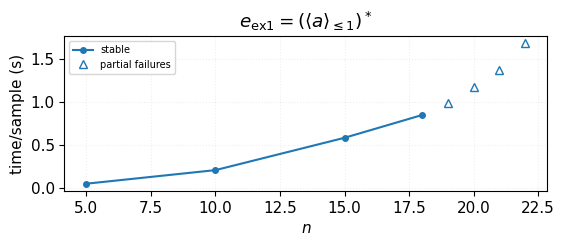

In [6]:
N_VALUES_EX1 = [5, 10, 15, 18, 19, 20, 21, 22]  # 22 expected to fail entirely

times_ex1, fails_ex1 = collect(
    phi_ex1, 'ex1', N_VALUES_EX1, 'n',
    k_of=lambda n: K, sample_kw=lambda n: dict(n=n))

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
stress_plot(ax, N_VALUES_EX1, times_ex1, fails_ex1, r'$n$',
            r'$e_{\mathrm{ex1}}=(\langle a\rangle_{\leq 1})^*$')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_ex1.pdf'), bbox_inches='tight')
plt.show()


## $e_{\mathrm{ex2}} = a^*\!\cdot\!\langle aa\rangle_{\leq 1}\!\cdot\! a^*$

$T=0.5$ fixed (untimed stars → infinite volume). Log-scale $y$-axis shows super-polynomial growth.

=== ex2: budget 1200s (20 min) ===
  n=2  target=5 samples  cell_elapsed=0s
     1/5  this=0.06s  pt_total=0.1s
     2/5  this=0.02s  pt_total=0.1s
     3/5  this=0.01s  pt_total=0.1s
     4/5  this=0.02s  pt_total=0.1s
     5/5  this=0.02s  pt_total=0.1s
  -> eff=0.03s/sample  wall=0.1s  successes=5
  n=5  target=5 samples  cell_elapsed=0s
     1/5  this=0.16s  pt_total=0.2s
     2/5  this=0.23s  pt_total=0.4s
     3/5  this=0.47s  pt_total=0.9s
     4/5  this=0.30s  pt_total=1.2s
     5/5  this=0.33s  pt_total=1.5s
  -> eff=0.30s/sample  wall=1.5s  successes=5
  n=10  target=5 samples  cell_elapsed=2s
     1/5  this=0.80s  pt_total=0.8s
     2/5  this=2.62s  pt_total=3.4s
     3/5  this=1.02s  pt_total=4.4s
     4/5  this=0.36s  pt_total=4.8s
     5/5  this=0.24s  pt_total=5.0s
  -> eff=1.01s/sample  wall=5.1s  successes=5
  n=15  target=5 samples  cell_elapsed=7s
     1/5  this=17.76s  pt_total=17.8s
     2/5  this=4.71s  pt_total=22.5s
     3/5  this=1.51s  pt_total=24.0s
     4/5 

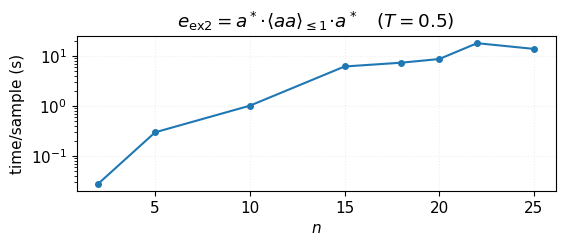

In [7]:
N_VALUES_EX2 = [2, 5, 10, 15, 18, 20, 22, 25]
T_EX2 = 0.5

times_ex2, fails_ex2 = collect(
    phi_ex2, 'ex2', N_VALUES_EX2, 'n',
    k_of=lambda n: K,
    sample_kw=lambda n: dict(n=n, T=T_EX2))

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
stress_plot(ax, N_VALUES_EX2, times_ex2, fails_ex2, r'$n$',
            r'$e_{\mathrm{ex2}}=a^*\!\cdot\!\langle aa\rangle_{\leq 1}\!\cdot\! a^*\quad(T=0.5)$',
            yscale='log')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_ex2.pdf'), bbox_inches='tight')
plt.show()

## $e_{\mathrm{ex3}} = (\langle aa\rangle_{\leq 1}\cdot a)\cap(a\cdot\langle aa\rangle_{\leq 1})$

$n=3$ fixed, $T\in(0,2)$. Language is empty at $T\geq 2$ (constraint $\tau_2\leq 2-T$).

=== ex3: budget 1200s (20 min) ===
  T=0.1  target=5 samples  cell_elapsed=0s
     1/5  this=0.02s  pt_total=0.0s
     2/5  this=0.02s  pt_total=0.0s
     3/5  this=0.01s  pt_total=0.1s
     4/5  this=0.01s  pt_total=0.1s
     5/5  this=0.01s  pt_total=0.1s
  -> eff=0.02s/sample  wall=0.1s  successes=5
  T=0.25  target=5 samples  cell_elapsed=0s
     1/5  this=0.01s  pt_total=0.0s
     2/5  this=0.01s  pt_total=0.0s
     3/5  this=0.01s  pt_total=0.0s
     4/5  this=0.01s  pt_total=0.1s
     5/5  this=0.01s  pt_total=0.1s
  -> eff=0.01s/sample  wall=0.1s  successes=5
  T=0.5  target=5 samples  cell_elapsed=0s
     1/5  this=0.02s  pt_total=0.0s
     2/5  this=0.01s  pt_total=0.0s
     3/5  this=0.01s  pt_total=0.0s
     4/5  this=0.01s  pt_total=0.1s
     5/5  this=0.01s  pt_total=0.1s
  -> eff=0.01s/sample  wall=0.1s  successes=5
  T=0.75  target=5 samples  cell_elapsed=0s
     1/5  this=0.02s  pt_total=0.0s
     2/5  this=0.01s  pt_total=0.0s
     3/5  this=0.01s  pt_total=0.0s
     

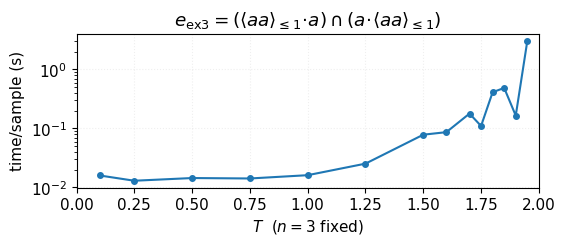

In [8]:
T_VALUES_EX3 = [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.6, 1.7, 1.75, 1.8, 1.85, 1.9, 1.95]

times_ex3, fails_ex3 = collect(
    phi_ex3, 'ex3', T_VALUES_EX3, 'T',
    k_of=lambda T: K,
    sample_kw=lambda T: dict(n=3, T=T))

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
stress_plot(ax, T_VALUES_EX3, times_ex3, fails_ex3, r'$T$  ($n=3$ fixed)',
            r'$e_{\mathrm{ex3}}=(\langle aa\rangle_{\leq 1}\!\cdot\! a)\cap(a\!\cdot\!\langle aa\rangle_{\leq 1})$',
            yscale='log')
ax.set_xlim(0, 2)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_ex3.pdf'), bbox_inches='tight')
plt.show()

### $e_{\mathrm{ex3}}$ — subexpression volumes and sampling time

The two arms of the intersection are

$$e_A = \langle aa\rangle_{\leq 1}\cdot a \qquad \texttt{(<a . a>\_[0,1] . a)}$$
$$e_B = a\cdot\langle aa\rangle_{\leq 1} \qquad \texttt{(a . <a . a>\_[0,1])}$$

Their slice-volumes are computed below via `slice_volume` for $n=3$.
The volume of $e_A\cap e_B$ is **not** derived analytically; its influence
is visible in the sampling-time curve instead: as $T\to 2$ the intersection
language shrinks, rejection sampling retries multiply, and wall-clock time blows up.


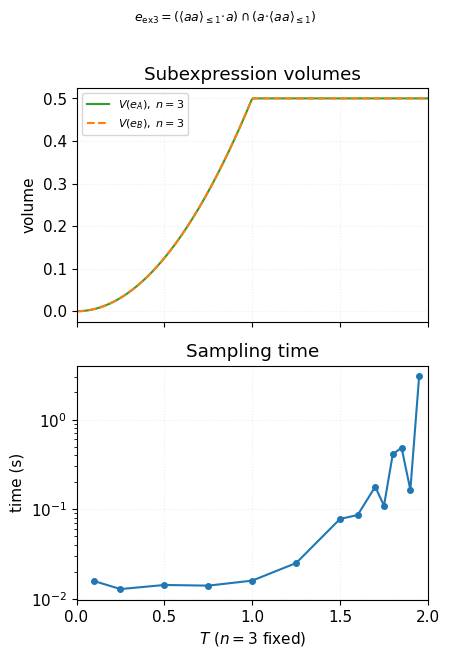

In [9]:
# Compute V(eA) and V(eB) for n=3 via slice_volume
T_vol_np = np.linspace(0.005, 1.995, 300)

vp_A = slice_volume(phi_ex3_left,  3)
vp_B = slice_volume(phi_ex3_right, 3)

vol_A = [float(vp_A(float(t))) for t in T_vol_np]
vol_B = [float(vp_B(float(t))) for t in T_vol_np]

xs_ok  = [T for T in T_VALUES_EX3 if times_ex3.get(T)]
means3 = [np.mean(times_ex3[T]) for T in xs_ok]

fig, axes = plt.subplots(2, 1, figsize=(FIG_W * 0.8, FIG_H * 2.5), sharex=True)

ax = axes[0]
ax.plot(T_vol_np, vol_A, color='#2ca02c', lw=1.5, label=r'$V(e_A),\; n=3$')
ax.plot(T_vol_np, vol_B, color='#ff7f0e', lw=1.5, linestyle='--', label=r'$V(e_B),\; n=3$')
ax.set_ylabel('volume')
ax.set_title('Subexpression volumes')
ax.set_xlim(0, 2)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, linestyle=':')

ax = axes[1]
ax.plot(xs_ok, means3, color=COLOR_MEAN, marker='o', markersize=4, lw=1.5)
ax.set_yscale('log')
ax.set_xlabel(r'$T$ ($n=3$ fixed)')
ax.set_ylabel('time (s)')
ax.set_title('Sampling time')
ax.set_xlim(0, 2)
ax.grid(True, alpha=0.2, linestyle=':')

fig.suptitle(
    r'$e_{\mathrm{ex3}}=(\langle aa\rangle_{\leq 1}\!\cdot\! a)'
    r'\cap(a\!\cdot\!\langle aa\rangle_{\leq 1})$',
    fontsize=9, y=1.01)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_ex3_volume.pdf'), bbox_inches='tight')
plt.show()


## $e_{\mathrm{exb}} = \langle b\rangle^*_{[3,4]}\!\cdot\!(\langle a\rangle_{[1,2]}\!\cdot\!\langle b\rangle_{[3,4]}\!\cdot\!\langle b\rangle^*_{[3,4]})^*$

All atoms bounded $\Rightarrow$ finite volume, $T$ auto-sampled. 
At $n\geq 12$ mpmath precision fails (large $T\sim 40$+ triggers same threshold as $e_{\mathrm{ex1}}$).

=== exb: budget 1200s (20 min) ===
  n=3  target=5 samples  cell_elapsed=0s
     1/5  this=0.06s  pt_total=0.1s
     2/5  this=0.03s  pt_total=0.1s
     3/5  this=0.03s  pt_total=0.1s
     4/5  this=0.03s  pt_total=0.1s
     5/5  this=0.03s  pt_total=0.2s
  -> eff=0.04s/sample  wall=0.2s  successes=5
  n=4  target=5 samples  cell_elapsed=0s
     1/5  this=0.13s  pt_total=0.1s
     2/5  this=0.05s  pt_total=0.2s
     3/5  this=0.04s  pt_total=0.2s
     4/5  this=0.04s  pt_total=0.3s
     5/5  this=0.04s  pt_total=0.3s
  -> eff=0.06s/sample  wall=0.3s  successes=5
  n=5  target=5 samples  cell_elapsed=0s
     1/5  this=0.34s  pt_total=0.3s
     2/5  this=0.06s  pt_total=0.4s
     3/5  this=0.06s  pt_total=0.5s
     4/5  this=0.06s  pt_total=0.5s
     5/5  this=0.07s  pt_total=0.6s
  -> eff=0.12s/sample  wall=0.6s  successes=5
  n=6  target=5 samples  cell_elapsed=1s
     1/5  this=0.76s  pt_total=0.8s
     2/5  this=0.08s  pt_total=0.8s
     3/5  this=0.08s  pt_total=0.9s
     4/5  this=

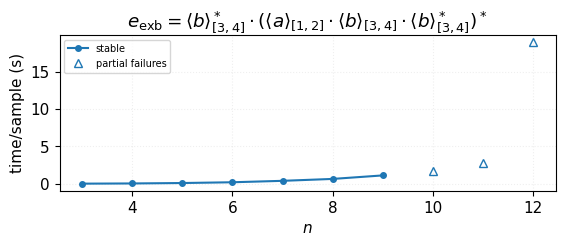

In [10]:
N_VALUES_EXB = [3, 4, 5, 6, 7, 8, 9, 10, 11, 12]  # 12 expected to fail entirely

times_exb, fails_exb = collect(
    phi_exb, 'exb', N_VALUES_EXB, 'n',
    k_of=lambda n: K,
    sample_kw=lambda n: dict(n=n))

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
stress_plot(ax, N_VALUES_EXB, times_exb, fails_exb, r'$n$',
            r'$e_{\mathrm{exb}}=\langle b\rangle^*_{[3,4]}\cdot'
            r'(\langle a\rangle_{[1,2]}\cdot\langle b\rangle_{[3,4]}\cdot\langle b\rangle^*_{[3,4]})^*$')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, '11_stress_exb.pdf'), bbox_inches='tight')
plt.show()

## Why mpmath fails at large $n$ — a precise account

### The code path

Every time VolTRE samples a duration $T_1$ for a subexpression (e.g. the left branch
of a concatenation), it runs through three steps inside `VolumePoly.inverse_sampling`
(`volume/VolumePoly.py`, line 615):

1. **Build the CDF.** Normalise the volume polynomial $V_n(T)$ by the total volume,
   then integrate symbolically.  The CDF is still a piecewise polynomial with exact
   rational sympy coefficients — no floating-point involved yet.

2. **Find the bracket.** Scan the pieces to locate $[a, b]$ with $\mathrm{CDF}(a) \le u \le \mathrm{CDF}(b)$
   for the drawn $u \sim \mathrm{Uniform}[0,1]$.

3. **Invert via bisection (this is where mpmath enters).**
   ```python
   f_num = sympy.lambdify(T, cdf_piece.as_expr() - u, 'mpmath')
   fa, fb = f_num(a), f_num(b)
   if fa * fb >= 0:
       raise InverseSamplingException(...)   # ← the crash
   root = mp.findroot(f_num, (a, b), solver='bisect')
   ```
   `lambdify(..., 'mpmath')` converts the sympy polynomial into a callable that
   evaluates in **mpmath's current working precision** — by default `mp.dps = 15`,
   i.e. $\approx 50$ bits, the same as `float64`.

---

### Why the sign check fails: catastrophic cancellation

For $e_{\mathrm{ex1}} = (\langle a\rangle_{\leq 1})^*$ the CDF on the piece $[1, 2]$ is
the integral of the PDF, which itself comes from the inclusion-exclusion formula for
the volume of an $n$-simplex restricted to a unit hypercube:

$$V_n(T) = \frac{1}{n!}\sum_{k=0}^{\lfloor T \rfloor}(-1)^k\binom{n}{k}(T-k)^n$$

On the piece $[1, 2]$ (two terms, $k=0$ and $k=1$):

$$V_n(T) = \frac{T^n - n\,(T-1)^n}{n!}$$

Each summand is $O(1)$ in magnitude, but they nearly cancel: the result is
$O(T^n/n!)$ which for $T \approx 1.5$, $n = 22$ is roughly
$1.5^{22}/22! \approx 10^{-15}$.  You are subtracting two numbers of order 1 to
extract a result of order $10^{-15}$ — exactly the noise floor of 15-digit arithmetic.
The polynomial evaluated at floating-point precision has the **wrong sign** with high
probability, so `fa * fb >= 0` triggers and an `InverseSamplingException` is raised.

**Why $n \approx 22$ specifically?** The magnitude of the leading coefficient is
$T^n / n!$.  With $T \sim 1$ we need $n! \lesssim 10^{15}$ (the precision budget) for
reliable evaluation.  $21! \approx 5 \times 10^{19}$ is already too large; in practice
failures start appearing at $n = 20$ (occasional) and are total by $n = 22$.

**Why $n \approx 11$ for $e_{\mathrm{exb}}$?** The bounded intervals $[3,4]$ force
large total durations — at $n = 10$ a typical word has $T \approx 35$.  The
inclusion-exclusion term $(T-k)^n$ with $T - k \sim 35$ gives
$35^{10} \approx 2.8 \times 10^{15}$ even without the factorial.  Combined with the
factorial denominator the coefficients saturate 15-digit precision already at $n \sim 10$–$11$.

---

### Proposed fix

The root cause is a single hard-coded precision.  The fix is to temporarily raise it
around the `findroot` call in `VolumePoly.inverse_sampling`:

```python
# in volume/VolumePoly.py, replace the three lines:
#   fa, fb = f_num(a), f_num(b)
#   if fa * fb >= 0: raise InverseSamplingException(...)
#   root = mp.findroot(f_num, (a, b), solver='bisect')
# with:

_dps = max(mp.dps, 3 * n + 10)   # heuristic: n extra decimal digits
with mp.workdps(_dps):
    fa, fb = f_num(a), f_num(b)
    if fa * fb >= 0:
        raise InverseSamplingException(
            f"Sign check failed: f(a)={fa}, f(b)={fb} on [{a},{b}]"
        )
    root = mp.findroot(f_num, (a, b), solver='bisect')
```

`mp.workdps` is a context manager that temporarily sets precision and restores it on
exit — thread-safe, no global side effects.  The heuristic `3*n + 10` extra decimal
digits is conservative; in practice `n + 20` is already enough for the expressions
in this paper.

**Upsides:**
- Completely eliminates the failure for $e_{\mathrm{ex1}}$ up to $n \approx 50$–$60$
  and for $e_{\mathrm{exb}}$ up to $n \approx 20$–$25$ — well beyond what the paper
  needs.
- The fix is localised to one function; no change to the symbolic volume computation.
- `mp.workdps` is cheap (two integer assignments); overhead is in the evaluation of
  the polynomial at higher precision.

**Downsides:**
- **Slower per sample.** mpmath bisection converges at $O(\log_2(1/\varepsilon))$
  iterations where $\varepsilon$ is the target precision.  Going from 50 bits to
  $\sim 3n$ bits at $n = 22$ means roughly $3 \times$ more iterations, each evaluating
  a degree-$n$ polynomial at higher precision.  Rough slowdown: **$2$–$4\times$ per
  sample** in the failing regime, negligible for small $n$.
- **There is still an asymptotic wall.** For very large $n$ the required precision
  grows linearly in $n$, and mpmath evaluation of an $n$-degree polynomial at
  $p$-bit precision costs $O(n \cdot p)$ bit-operations per polynomial evaluation.
  Bisection needs $O(p)$ iterations.  Total cost per sample is $O(n \cdot p^2)$
  where $p = O(n)$, i.e. $O(n^3)$ — a cube in $n$.  At $n = 100$ this becomes
  noticeable; at $n = 200$ it will be the bottleneck.
- **The heuristic $3n + 10$ is not proven tight.** For expressions with bounded
  intervals and large $T$ (like $e_{\mathrm{exb}}$) you may need more digits; add a
  $+\lceil n \log_{10} T_{\max} \rceil$ term if needed.
